# Initial Setup

In [126]:

import numpy as np
import pandas as pd
from scipy.stats import entropy

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    OrdinalEncoder
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor


car_data = pd.read_csv('../data/car_data.csv')


# 🔎 Data Preprocessing

In [127]:
# Converting column names from PascalCase to snake_case

new_columns = []

for col in car_data.columns:
    result = ""
    for i, char in enumerate(col):
        if char.isupper() and i != 0:
            result += "_" + char.lower()
        else:
            result += char.lower()
    new_columns.append(result)

car_data.columns = new_columns
print(car_data.columns)

Index(['date_crawled', 'price', 'vehicle_type', 'registration_year', 'gearbox',
       'power', 'model', 'mileage', 'registration_month', 'fuel_type', 'brand',
       'not_repaired', 'date_created', 'number_of_pictures', 'postal_code',
       'last_seen'],
      dtype='str')


In [128]:
# Identifying columns with missing values

nan_values = car_data.isna().sum().sort_values(ascending=False)
columns_nan = nan_values[nan_values > 0]
print(columns_nan)

not_repaired    71154
vehicle_type    37490
fuel_type       32895
gearbox         19833
model           19705
dtype: int64


In [129]:
# Percentage of NaN values per column

for i in range(len(columns_nan)):
    percentage = (columns_nan.iloc[i] * 100) / len(car_data)
    print(f"{columns_nan.index[i]}: {round(percentage, 3)} %")

not_repaired: 20.079 %
vehicle_type: 10.579 %
fuel_type: 9.283 %
gearbox: 5.597 %
model: 5.561 %


In [130]:
# Filling NaN values

cols_nan = ['not_repaired', 'vehicle_type', 'fuel_type', 'gearbox', 'model']

car_data[cols_nan] = car_data[cols_nan].fillna('unknown')

Missing values in the categorical variables of used car advertisements are not randomly distributed. In many cases, the absence of information reflects user behavior—such as a lack of knowledge, a lack of interest in completing the profile, or a conscious decision to omit certain details—and may be correlated with the vehicle's price.

In [131]:
# Converting date columns from string to datetime format for proper date operations

car_data['date_crawled'] = pd.to_datetime(car_data['date_crawled'],
                                          format="%d/%m/%Y %H:%M")

car_data['date_created'] = pd.to_datetime(car_data['date_created'],
                                          format="%d/%m/%Y %H:%M")

car_data['last_seen'] = pd.to_datetime(car_data['last_seen'],
                                       format="%d/%m/%Y %H:%M")

In [132]:
# Removing postal_code to reduce noise and improve model performance

car_data = car_data.drop(columns=['postal_code'])

In [133]:
# Removing duplicated values

car_data = car_data.drop_duplicates()

print(car_data.duplicated().sum())

0


Given that the objective of the project is to estimate a vehicle's market value based on user-provided information, each row in the dataset should represent a unique listing from a user.

The dataset includes temporal and interaction variables such as DateCrawled, DateCreated, and LastSeen, which suggest that the records correspond to profiles created and managed by users within the platform. In this context, the existence of completely duplicate rows is highly improbable from the perspective of user behavior, as it would imply that different users entered exactly the same vehicle information on the same dates and at the same price.

## Numerical variables

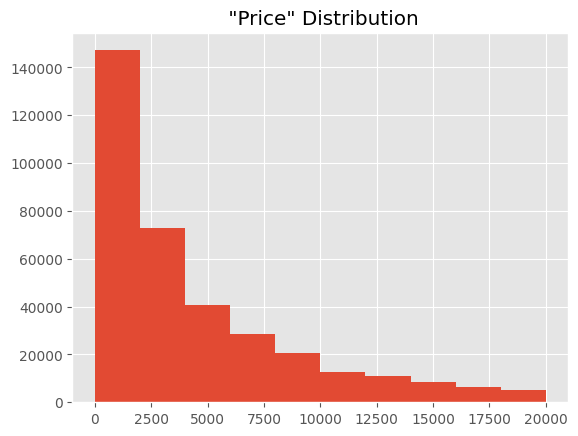

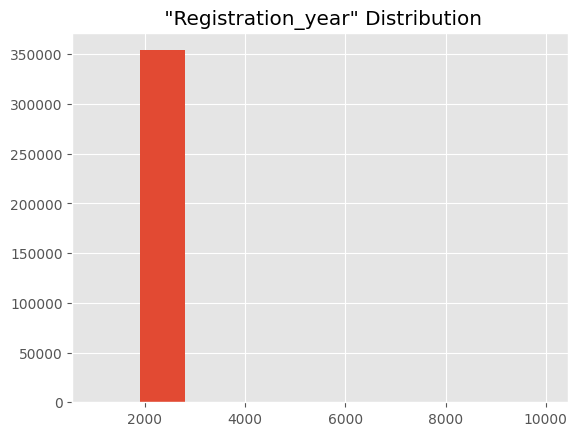

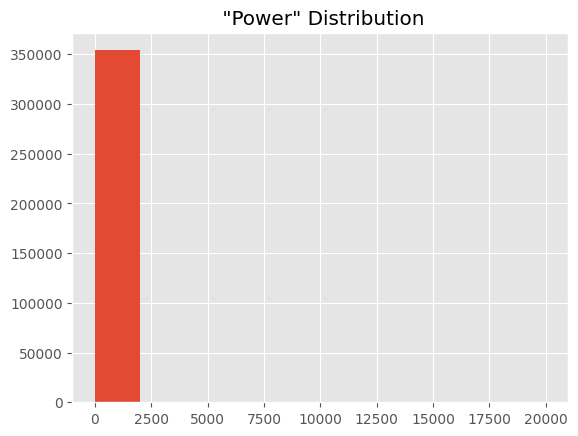

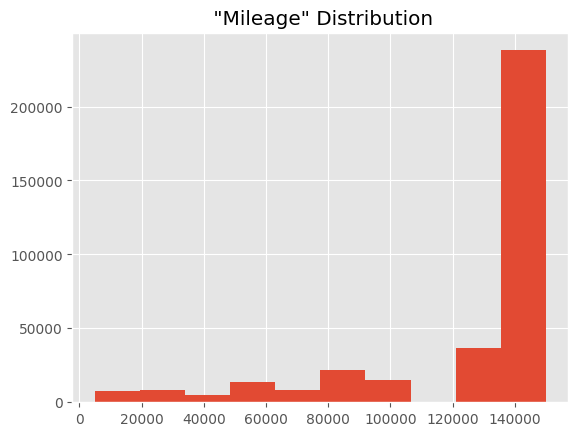

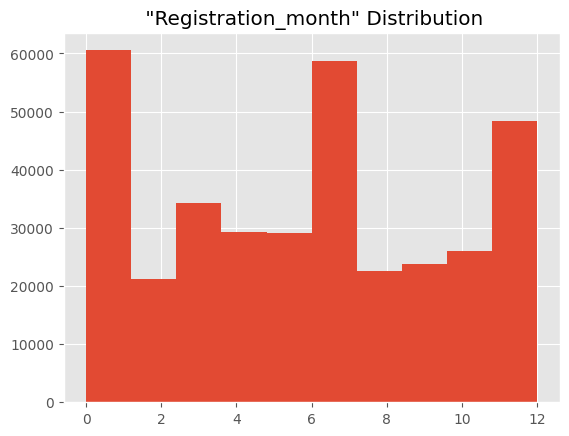

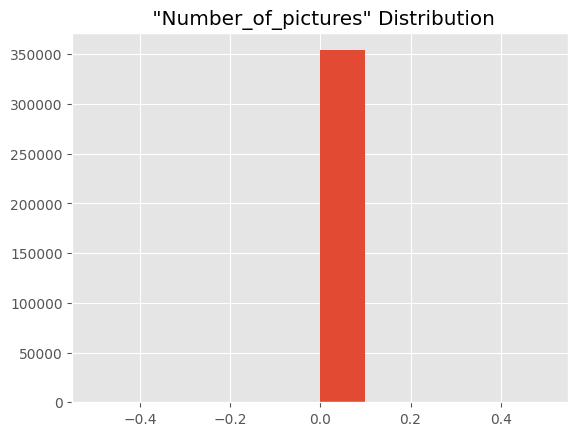

In [134]:
# Visualizing distribution of numerical columns

for col in car_data.select_dtypes(include='int').columns:

    plt.style.use('ggplot')
    plt.hist(car_data[col])
    plt.title(f""" "{col.capitalize()}" Distribution""")

    plt.show()

In [135]:
# Analyzing numerical columns

car_data.select_dtypes(include='int').describe()

,price,registration_year,power,mileage,registration_month,number_of_pictures
count,354070.000000,354070.000000,354070.000000,354070.000000,354070.000000,354070.0
mean,4416.121061,2004.235058,110.086234,128214.547971,5.714102,0.0
std,4514.267512,90.265836,189.924003,37905.191996,3.726729,0.0
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0


In [136]:
# Dropping 'number_of_pictures' column due to zero variance (all values = 0)

car_data = car_data.drop(columns=['number_of_pictures'])

In [137]:
# Selecting rows with price over 500

car_data = car_data[car_data['price'] > 500]

Rows with a price below €500 were removed. This decision is based on the fact that values near zero do not represent the actual market value of a functional vehicle. Such entries would act as statistical 'noise,' negatively impacting the accuracy and quality of the model's predictions.

In [138]:
# Analyzing unique values in the 'registration_year' column

car_data['registration_year'].value_counts().head(10)

registration_year
2005    20965
2006    19573
2000    19237
2004    19171
2003    19138
1999    18848
2001    18427
2002    18144
2007    16931
2008    15189
Name: count, dtype: int64

In [139]:
# Analyzing highest and lowest registration years to detect outliers and data entry errors

print("Highest unique values in the 'registration_year' column:")
print(car_data['registration_year'].value_counts().index.sort_values(ascending=False)[:40].tolist())
print()
print("Lowest unique values in the 'registration_year' column:")
print((car_data['registration_year'].value_counts()
    .index.sort_values(ascending=False)[len(car_data['registration_year'].value_counts())-50:].tolist()))

Highest unique values in the 'registration_year' column:
[9999, 9450, 9000, 8888, 8500, 7800, 7100, 7000, 6000, 5911, 5555, 5300, 5000, 4500, 4100, 4000, 3700, 3200, 3000, 2900, 2800, 2500, 2290, 2066, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004]

Lowest unique values in the 'registration_year' column:
[1966, 1965, 1964, 1963, 1962, 1961, 1960, 1959, 1958, 1957, 1956, 1955, 1954, 1953, 1952, 1951, 1950, 1949, 1948, 1947, 1946, 1945, 1944, 1943, 1942, 1941, 1940, 1938, 1937, 1936, 1935, 1934, 1933, 1932, 1931, 1930, 1929, 1928, 1927, 1925, 1923, 1910, 1800, 1600, 1500, 1400, 1234, 1039, 1001, 1000]


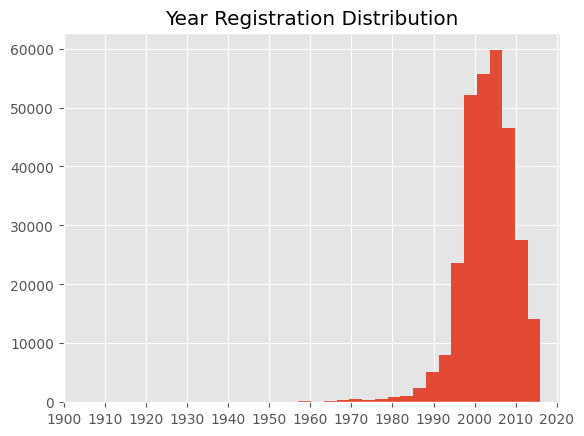

In [140]:
# Deeper look at the 'registration_year' column distribution wihtout outliers

car_data = car_data[(car_data['registration_year'] > 1920) & (car_data['registration_year'] < 2017)]

plt.style.use('ggplot')
plt.hist(car_data['registration_year'], bins=30)
plt.title("Year Registration Distribution")
plt.xticks(range(1900, 2030, 10))
plt.show()

In [141]:
# Defining a new range of values for the 'registration_year' column

car_data = car_data[(car_data['registration_year'] > 1980)
                    & (car_data['registration_year'] < 2017)]

The range for the registration_year column was restricted to between 1980 and 2016. The upper limit was set at 2016 to maintain logical consistency with the data collection date, thereby eliminating records with impossible future years. On the other hand, the lower limit of 1980 allows the model to focus on the primary concentration of the data distribution, discarding erroneous values (such as the years 1000 or 1234) and collector vehicles that do not follow mass-market depreciation trends.

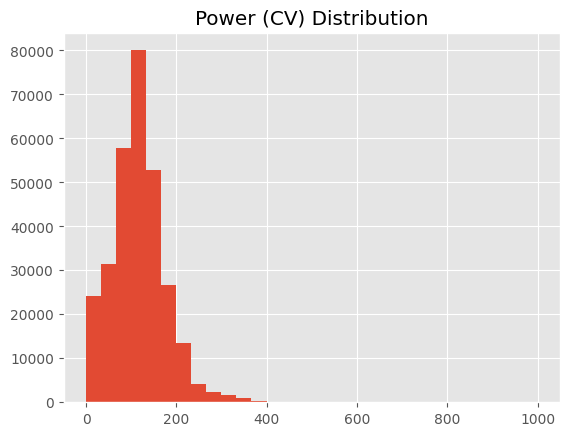

In [142]:
# Deeper look at the 'power' column distribution, without outliers

car_power = car_data[car_data['power'] < 1000]

plt.style.use('ggplot')
plt.hist(car_power['power'], bins=30)
plt.title("Power (CV) Distribution")
plt.show()

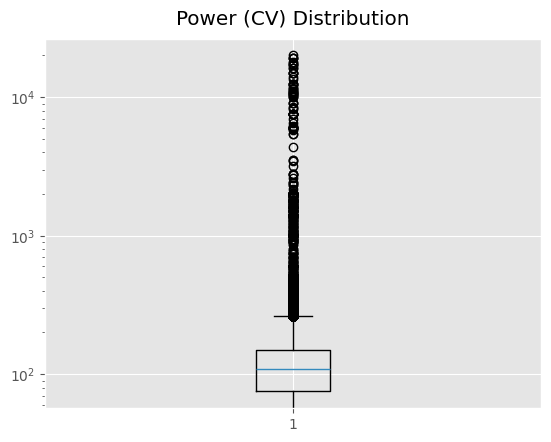

In [143]:
# Boxplot in logarithmic scale for the 'power' column

plt.boxplot(car_data['power'])
plt.yscale('log')
plt.title("Power (CV) Distribution", pad=10)
plt.show()

In [144]:
# Analyzing brands with the most extreme outliers

car_data[car_data['power'] > 5000]['brand'].value_counts()

brand
volkswagen       15
opel             11
bmw               7
audi              6
ford              5
smart             3
mercedes_benz     3
renault           3
fiat              2
alfa_romeo        2
toyota            1
suzuki            1
kia               1
mini              1
chevrolet         1
peugeot           1
citroen           1
mitsubishi        1
Name: count, dtype: int64

In [145]:
# Analyzing number of rows that will be dropped after the filter

car_data[car_data['power'] > 600].shape[0]

277

In [146]:
# Selecting rows with 'power' below 600 CV and replacing values from 0 to 10 CV with the median of each brand

car_data = car_data[car_data['power'] < 600]

car_data.loc[car_data['power'] < 10, 'power'] = np.nan

car_data['power'] = car_data['power'].fillna(
    car_data.groupby(['brand', 'model'])['power'].transform('median')
)

car_data['power'] = car_data['power'].fillna(
    car_data.groupby('brand')['power'].transform('median')
)

car_data['power'] = car_data['power'].astype(int)

The processing of the power variable focused on physical and technical consistency. Records with power outputs exceeding 600 HP were removed, as these were identified as entry errors for mass-market brands. Similarly, values below 10 HP (including zeros and single-digit values) were treated as missing data and imputed using the median grouped by brand and model. This approach preserves the dataset size while eliminating statistical noise.

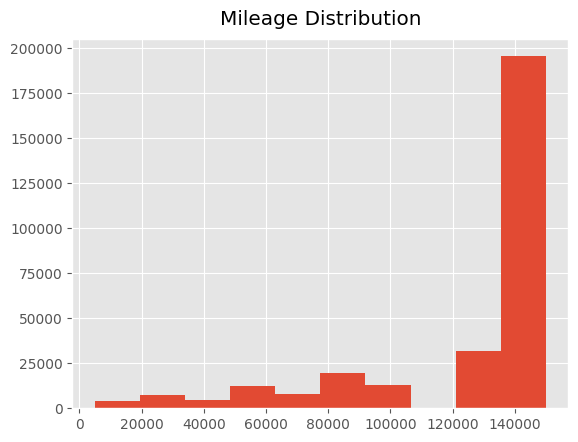

In [147]:
# Deeper look at the 'mileage' column distribution

plt.style.use("ggplot")
plt.hist(car_data['mileage'])
plt.title('Mileage Distribution', pad=10)
plt.show()

In [148]:
# Analyzing 'mileage' unique values distribution

car_data['mileage'].value_counts(normalize=True)

mileage
150000    0.660559
125000    0.108133
100000    0.043316
90000     0.035144
80000     0.030761
70000     0.026563
60000     0.023231
50000     0.019287
40000     0.015414
30000     0.013305
20000     0.011207
5000      0.009973
10000     0.003106
Name: proportion, dtype: float64

The mileage variable consists of discrete values with a high concentration at 150,000 km. This value is not considered an error, but rather an indicator of high vehicle usage. Consequently, no imputations or removals were performed on this column, as it retains relevant information for price estimation.

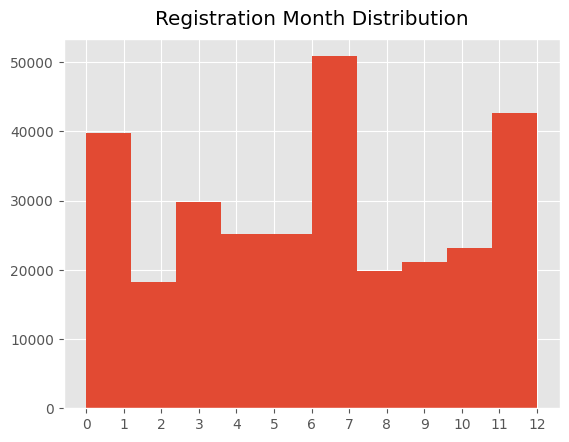

In [149]:
# Analyzing 'registration_month' distribution

plt.style.use('ggplot')
plt.hist(car_data['registration_month'])
plt.title("Registration Month Distribution", pad=10)
plt.xticks(range(0, 13))
plt.show()

In [150]:
# Analyzing 'registration_month' unique values distribution

car_data['registration_month'].value_counts().sort_index(ascending=False)

registration_month
12    21223
11    21469
10    23135
9     21071
8     19805
7     23564
6     27294
5     25235
4     25228
3     29788
2     18260
1     19727
0     20096
Name: count, dtype: int64

In [151]:
# Replacing zeros in the 'registration_month' column with a 'sentinel' value, in this case 13

car_data['registration_month'] = car_data['registration_month'].replace(0, 13)

The value 0 in the registration_month variable represents an unreported month. To avoid introducing an incorrect numerical order and to ensure compatibility with linear models, this value was treated as missing data and replaced with a sentinel value (13). This explicitly indicates an 'unknown month' without interfering with the valid months (1–12).

## Categorical variables

In [152]:
# Analyzing categorical columns

categorical_columns = car_data.select_dtypes(include=['object', 'str'])
categorical_columns.describe()

,vehicle_type,gearbox,model,fuel_type,brand,not_repaired
count,295895,295895,295895,295895,295895,295895
unique,9,3,249,8,40,3
top,sedan,manual,golf,petrol,volkswagen,no
freq,82900,224792,24183,180046,63784,226018


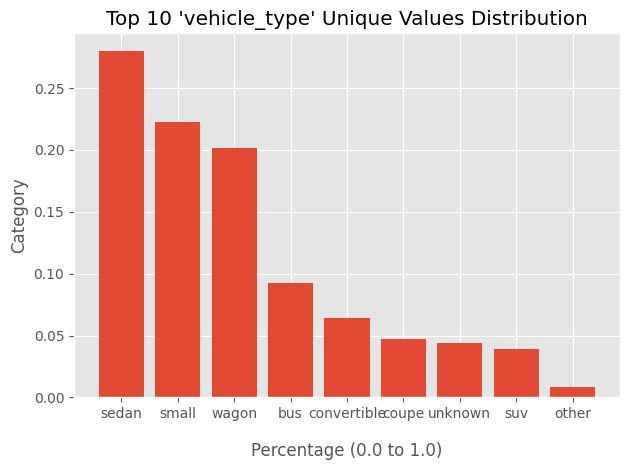

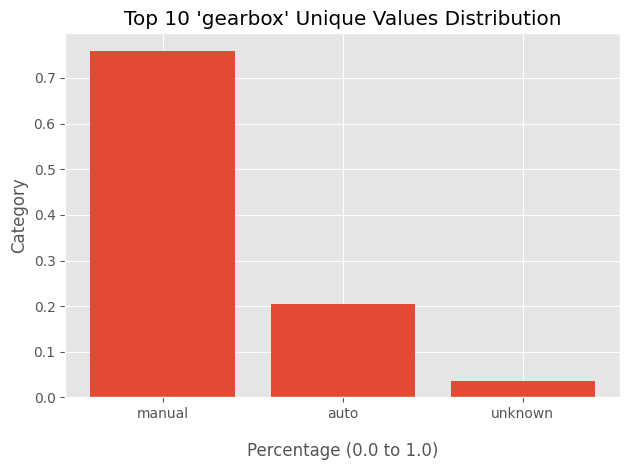

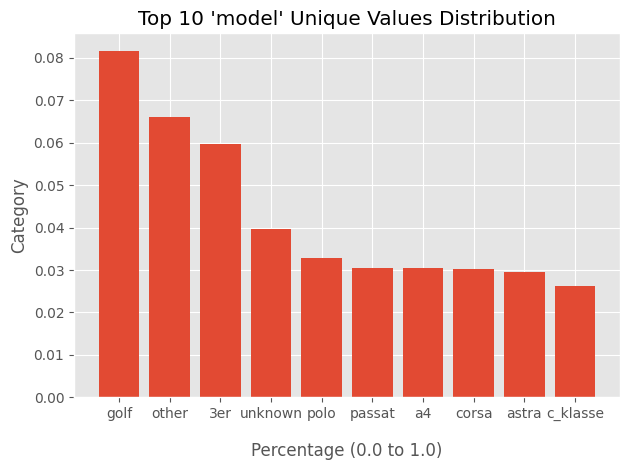

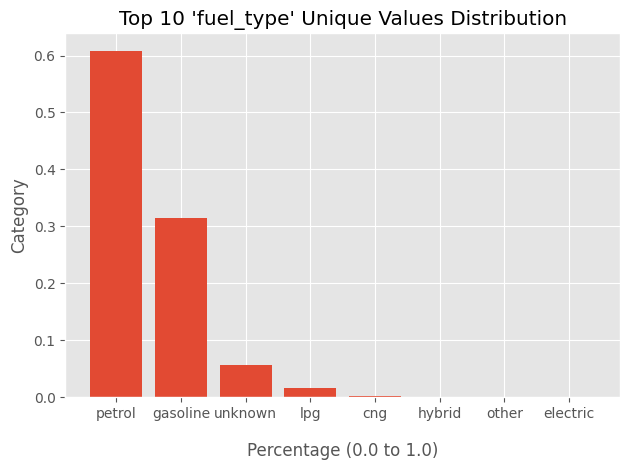

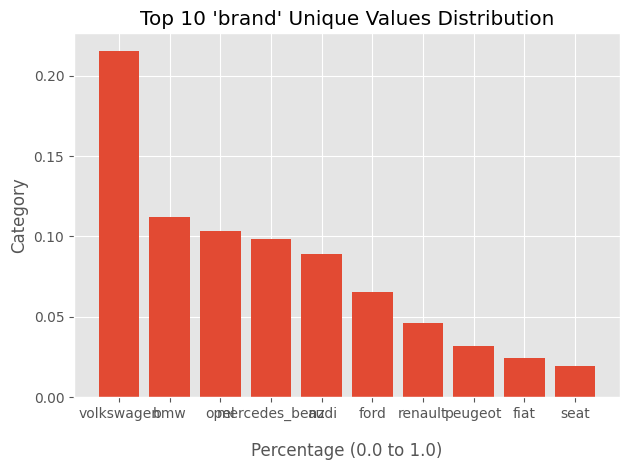

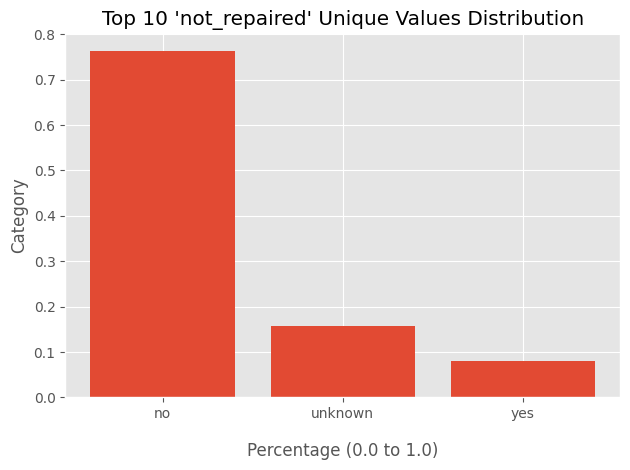

<Figure size 640x480 with 0 Axes>

In [153]:
# Analyzing unique values distribution in categorical columns

categorical_cols = ['vehicle_type', 'gearbox',
                    'model', 'fuel_type', 'brand', 'not_repaired']

for name_col in categorical_cols:

    plt.style.use('ggplot')
    distributions = car_data[name_col].value_counts(
        normalize=True).sort_values(ascending=False).head(10)
    plt.bar(distributions.index, distributions.values)

    plt.title(f"Top 10 '{name_col}' Unique Values Distribution")
    plt.xlabel('Percentage (0.0 to 1.0)', labelpad=15)
    plt.ylabel('Category')
    plt.tight_layout()

    plt.show()
    plt.clf()
    print()

In [154]:
# Analyzing cardinality and entropy in categorical columns

def normalized_entropy(series):
    probs = series.value_counts(normalize=True)
    return entropy(probs) / np.log(len(probs))


entropy_df = (
    pd.DataFrame({
        "column": categorical_cols,
        "n_unique": [car_data[col].nunique() for col in categorical_cols],
        "normalized_entropy": [normalized_entropy(car_data[col]) for col in categorical_cols]
    })
    .sort_values("normalized_entropy", ascending=False)
)

entropy_df

,column,n_unique,normalized_entropy
0,vehicle_type,9,0.846304
2,model,249,0.782566
4,brand,40,0.749620
5,not_repaired,3,0.634654
1,gearbox,3,0.595127
3,fuel_type,8,0.441637


In [155]:
# Grouping 'petrol' and 'gasoline' variables in the 'fuel_type' column

car_data['fuel_type'] = car_data['fuel_type'].replace({'petrol': 'gasoline'})

car_data['fuel_type'].value_counts()

fuel_type
gasoline    273163
unknown      17022
lpg           4813
cng            506
hybrid         216
other           94
electric        81
Name: count, dtype: int64

In [156]:
# Examining distribution of 'model' values to determine if grouping is needed for high cardinality

model_counts = car_data['model'].value_counts(normalize=True)
print(model_counts.head(10))
print()
print(model_counts.tail(20))

model
golf        0.081728
other       0.066044
3er         0.059721
unknown     0.039649
polo        0.032768
passat      0.030572
a4          0.030545
corsa       0.030203
astra       0.029554
c_klasse    0.026293
Name: proportion, dtype: float64

model
delta                 0.000091
b_max                 0.000088
move                  0.000088
musa                  0.000074
145                   0.000074
9000                  0.000071
materia               0.000061
200                   0.000057
charade               0.000047
q3                    0.000041
gl                    0.000041
kappa                 0.000041
amarok                0.000037
i3                    0.000020
kalina                0.000017
samara                0.000017
elefantino            0.000014
rangerover            0.000010
range_rover_evoque    0.000007
serie_2               0.000003
Name: proportion, dtype: float64


In [157]:
# Group rare car models based on frequency to reduce cardinality and improve generalization

threshold = 0.002

freq = car_data['model'].value_counts(normalize=True)
rare_models = freq[freq < threshold].index

car_data = car_data.copy()
car_data['model'] = car_data['model'].replace(rare_models, 'other')

print(f"Cardinality: ", car_data['model'].nunique())
print(f"Entropy:", round(normalized_entropy(car_data['model']), 3))

Cardinality:  79
Entropy: 0.817


In [158]:
# Long-tail distribution check after grouping rare model categories

model_counts_grouped = car_data['model'].value_counts(normalize=True)

print("Top-10 most frequent categories:\n")
print(model_counts_grouped.head(10))
print()
print("Bottom-10 least frequent categories:\n")
print(model_counts_grouped.tail(10))

Top-10 most frequent categories:

model
other       0.194136
golf        0.081728
3er         0.059721
unknown     0.039649
polo        0.032768
passat      0.030572
a4          0.030545
corsa       0.030203
astra       0.029554
c_klasse    0.026293
Name: proportion, dtype: float64

Bottom-10 least frequent categories:

model
sprinter    0.002345
arosa       0.002278
transit     0.002247
colt        0.002197
c_max       0.002160
tiguan      0.002156
corolla     0.002129
insignia    0.002085
panda       0.002055
tigra       0.002045
Name: proportion, dtype: float64


In [159]:
# Reviewing categorical columns

car_data.select_dtypes(include=['object', 'string']).describe()

,vehicle_type,gearbox,model,fuel_type,brand,not_repaired
count,295895,295895,295895,295895,295895,295895
unique,9,3,79,7,40,3
top,sedan,manual,other,gasoline,volkswagen,no
freq,82900,224792,57444,273163,63784,226018


After grouping infrequent car models based on their frequency, the variable's cardinality was reduced from 251 to 79. This process eliminated extremely rare categories while preserving the dominant models. The resulting distribution no longer contains values with extremely low frequencies, which improves statistical support and reduces model variance; however, normalized entropy increased due to a more balanced distribution among the remaining categories.

## Datetime variables

In [160]:
# Analyzing datetime columns

car_data.select_dtypes(include='datetime').describe()

,date_crawled,date_created,last_seen
count,295895,295895,295895
mean,2016-03-21 13:00:08.315990,2016-03-20 19:00:36.146606,2016-03-30 05:04:05.416110
min,2016-03-05 14:06:00,2014-03-10 00:00:00,2016-03-05 14:15:00
25%,2016-03-13 10:58:00,2016-03-13 00:00:00,2016-03-23 13:15:00
50%,2016-03-21 17:52:00,2016-03-21 00:00:00,2016-04-04 04:16:00
75%,2016-03-29 14:48:00,2016-03-29 00:00:00,2016-04-06 10:46:00
max,2016-04-07 14:36:00,2016-04-07 00:00:00,2016-04-07 14:58:00


In [161]:
# Calculating age at the moment the car was registered and subtracting the month of the creation date

car_data['age_at_listing'] = car_data['date_created'].dt.year - \
    car_data['registration_year']

car_data['month_created'] = car_data['date_created'].dt.month

In [162]:
# Drop the old columns to remove the 'noise'

car_data.drop(['date_created', 'date_crawled', 'last_seen'], axis=1, inplace=True)

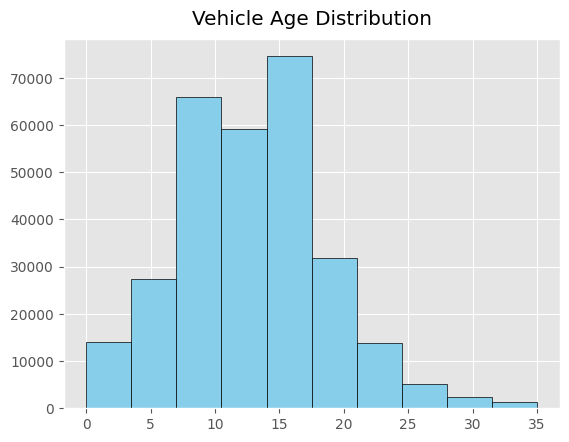

In [163]:
# Vehicle age distribution

plt.hist(car_data['age_at_listing'], color='skyblue', edgecolor='black')
plt.title("Vehicle Age Distribution", pad=10)
plt.show()

In [164]:
# Analyzing the 'month_created' columns unique values

car_data['month_created'].value_counts()

month_created
3     247433
4      48005
2        372
1         61
11         9
12         9
9          3
8          2
6          1
Name: count, dtype: int64

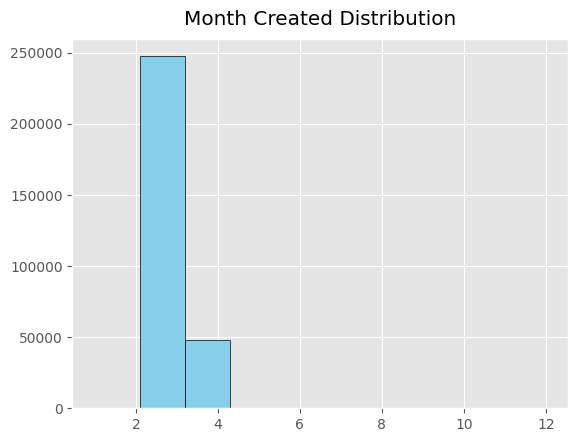

In [165]:
# Visualizing 'month_created' columns distribution

plt.hist(car_data['month_created'], color='skyblue', edgecolor='black')
plt.title("Month Created Distribution", pad=10)
plt.show()

In [166]:
# Verifying negative correlation between the columns 'price' and 'age_at_listing'

car_data[['age_at_listing', 'price']].corr()

,age_at_listing,price
age_at_listing,1.000000,-0.550779
price,-0.550779,1.000000


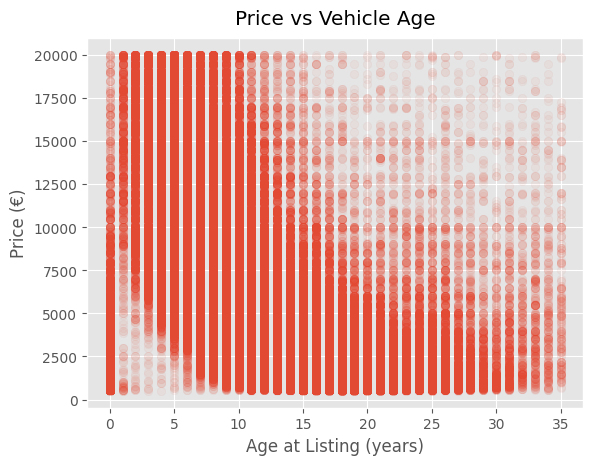

In [167]:
# Verifying prices go down as vahicle age increases

plt.figure()
plt.scatter(car_data['age_at_listing'], car_data['price'], alpha=0.05)
plt.xlabel('Age at Listing (years)')
plt.ylabel('Price (€)')
plt.title('Price vs Vehicle Age', pad=10)
plt.show()

Features with higher predictive power were extracted from the original datetime columns: the month the advertisement was created and the vehicle's age (calculated as the difference between the registration year and the listing year). These metrics enable the model to capture market seasonality and the numerical depreciation curve, eliminating the statistical noise of precise timestamps and improving the algorithm's ability to generalize.

In [168]:
# Resetting index

car_data = car_data.reset_index(drop=True)

In [169]:
# Removing 'registration_year' to avoid redundancy with 'age_at_listing'

car_data = car_data.drop(columns=['registration_year'])

# Categorical Encoding Pipeline

In [170]:
# Visualizing the amount of unique values in each categorical column

categorical_cols = car_data.select_dtypes(include=['object', 'string']).columns

categorical_unique = pd.DataFrame({
    'columns_name': categorical_cols,
    'num_unique': [car_data[col].nunique() for col in categorical_cols]
})

categorical_unique

,columns_name,num_unique
0,vehicle_type,9
1,gearbox,3
2,model,79
3,fuel_type,7
4,brand,40
5,not_repaired,3


In [171]:
# Splitting data and encoding categorical features

X = car_data.drop('price', axis=1)
y = car_data['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

low_card_cols = ['vehicle_type', 'gearbox', 'fuel_type', 'not_repaired']

high_card_cols = ['brand', 'model']

num_cols = ['power', 'mileage', 'registration_month',
            'age_at_listing', 'month_created']


preprocessor_linear = ColumnTransformer(
    transformers=[('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), low_card_cols),
                  ('target', Pipeline([
                      ('encoder', TargetEncoder(smoothing=5)),
                      ('scaler', StandardScaler())
                  ]), high_card_cols),
                  ('scaler', StandardScaler(), num_cols)
                  ],
    remainder='drop'
)

preprocessor_forest = ColumnTransformer(
    transformers=[('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), low_card_cols),
                  ('target', TargetEncoder(smoothing=5), high_card_cols),
                  ('num',  'passthrough', num_cols)
                  ],
    remainder='drop'
)

preprocessor_lgm = ColumnTransformer(
    transformers=[('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), low_card_cols + high_card_cols),
                  ('num',  'passthrough', num_cols)],
    remainder='drop'
)

Different categorical encoding strategies were applied based on column cardinality and the specific model type, utilizing pipelines to prevent data leakage and ensure a robust evaluation.

1. For the Linear Regressor model: Low-cardinality categorical variables were transformed using one-hot encoding, while high-cardinality variables were processed with target encoding to reduce dimensionality and capture target-relevant information. Numerical variables and target-encoded features were then scaled using standard scaling, as this model is sensitive to feature scale.

2. For the Random Forest Regressor: Ordinal encoding was used for low-cardinality variables and target encoding for high-cardinality ones. As an ensemble tree-based model, numerical feature scaling was not required.

3. For the LightGBM model: Ordinal encoding was used exclusively for all categorical variables, leveraging the model’s native ability to handle this encoding type efficiently during training.

# 🤖 Machine Learning

In [48]:
from sklearn.model_selection import ParameterGrid, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from IPython.display import display

def train_with_search(model, param_grid,
                           X_train, X_test,
                           y_train, y_test,
                           iterations=5,
                           fit_params=None):

    if not param_grid:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        print(f"\nBest RMSE: {mean_squared_error(y_test, preds)**0.5:.2f} \n")
        print(f"Best MAE: {mean_absolute_error(y_test, preds):.2f} \n")
        print(f"Best R²: {r2_score(y_test, preds):.2f} \n")
        return

    total_params = len(ParameterGrid(param_grid))
    actual_iter = min(iterations, total_params)

    search = RandomizedSearchCV(
        model,
        param_distributions=param_grid,
        n_iter=actual_iter,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=1,
        random_state=42
    )

    if fit_params:
      search.fit(X_train, y_train, **fit_params)
    else:
      search.fit(X_train, y_train)

    best_model = search.best_estimator_
    preds = best_model.predict(X_test)

    results = {
        'RMSE': f"{mean_squared_error(y_test, preds)**0.5:.2f}",
        'MAE': f"{mean_absolute_error(y_test, preds):.2f}",
        'R²': f"{r2_score(y_test, preds):.2f}"
    }

    print("\nBest Model Performance:")
    display(pd.DataFrame(results.values(), index=results.keys(), columns=['Score']))

    print("\nBest Params:")
    display(pd.DataFrame(search.best_params_, index=[0]).T.rename(columns={0: 'Value'}))

    return results, search.best_params_, best_model


## Dummy model (Baseline)

In [53]:
from sklearn.dummy import DummyRegressor

dummy_model = DummyRegressor(strategy='median')

dummy_model.fit(X_train, y_train)

train_with_search(dummy_model, {}, X_train, X_test, y_train, y_test)


Best RMSE: 4811.45 

Best MAE: 3323.76 

Best R²: -0.13 



## Linear Regressor

In [54]:

linear_pipeline = Pipeline([
    ('preprocessor', preprocessor_linear),
    ('regressor', LinearRegression())
])

param_grid_lr = {
    "regressor__fit_intercept": [True, False],
    "regressor__positive": [True, False]
}

linear_results, linear_params, linear_best_model = train_with_search(linear_pipeline, param_grid_lr, X_train, X_test, y_train, y_test)


Best Model Performance:


,Score
RMSE,2659.06
MAE,1940.74
R²,0.65



Best Params:


,Value
regressor__positive,False
regressor__fit_intercept,False


Hyperparameter tuning with RandomizedSearchCV significantly improved the Linear Regression model. Compared to the Dummy baseline (RMSE ≈ 4811, R² = -0.13), the tuned model reduced RMSE to 2659.06 and achieved an R² of 0.65, indicating it captures meaningful patterns in the data.

The optimal configuration retained the intercept and allowed both positive and negative coefficients. While this model provides a strong and interpretable baseline, its linear nature limits its ability to capture more complex relationships, motivating the use of non-linear models.

## Random  Forest Regressor

In [56]:

pipeline_forest = Pipeline([
    ('preprocessing', preprocessor_forest),
    ('forest', RandomForestRegressor(random_state=54321))
])


param_grid_rf = {
    "forest__n_estimators": [100, 200],
    "forest__max_depth": [None, 10],
    "forest__min_samples_split": [2, 5],
    "forest__min_samples_leaf": [1, 2],
    "forest__max_features": ["sqrt"]
}

rf_results, rf_params, rf_best_model = train_with_search(pipeline_forest, param_grid_rf, X_train, X_test, y_train, y_test)


Best Model Performance:


,Score
RMSE,1517.82
MAE,961.88
R²,0.89



Best Params:


,Value
forest__n_estimators,200
forest__min_samples_split,2
forest__min_samples_leaf,2
forest__max_features,sqrt
forest__max_depth,None


The Random Forest Regressor significantly outperformed the linear baseline, reducing RMSE from 2659.06 to 1517.82 and increasing R² from 0.65 to 0.89. This improvement highlights the strong non-linear relationships present in the data, which linear models fail to capture.

The best model utilized 200 trees with unrestricted depth, enabling it to learn complex feature interactions. A minimum leaf size of 2 introduced slight regularization, improving generalization without sacrificing performance.

These results confirm that tree-based ensemble methods are far better suited for this problem, establishing Random Forest as a strong and reliable model for vehicle price prediction.

## CatBoost Regressor

In [57]:

cat_model = CatBoostRegressor(
    verbose=False,
    random_state=54321
)

cat_features = X_train.select_dtypes(include='object').columns.tolist()

param_grid_cat = {
    "iterations": [200, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "depth": [4, 6, 8, 10],
    "l2_leaf_reg": [1, 3, 5, 7],
    "border_count": [32, 64, 128]
}

cat_results, cat_params, cat_best_model = train_with_search(cat_model, param_grid_cat, X_train, X_test, y_train, y_test, fit_params={"cat_features": cat_features})


Best Model Performance:


,Score
RMSE,1568.47
MAE,1010.28
R²,0.88



Best Params:


,Value
learning_rate,0.05
l2_leaf_reg,1.00
iterations,500.00
depth,10.00
border_count,64.00


The CatBoost Regressor delivered strong performance (RMSE = 1568.47, R² = 0.88), closely matching the Random Forest model while requiring significantly less preprocessing due to its native handling of categorical features.

Although Random Forest achieved slightly better accuracy, the difference is marginal, suggesting both models capture the underlying structure of the data effectively. The CatBoost model, configured with 500 iterations, depth 10, and a moderate learning rate (0.05), was able to model complex relationships with minimal manual feature engineering.

Given its competitive performance and simpler pipeline, CatBoost offers a more efficient and production-friendly solution, particularly in scenarios where preprocessing complexity and scalability are important considerations.

## LightGBM

In [59]:
import warnings
warnings.filterwarnings("ignore")


pipeline_lgbm = Pipeline([
    ('preprocessing', preprocessor_lgm),
    ('model', LGBMRegressor(verbose=0, random_state=54321))
])

param_grid_lgbm = {
    "model__n_estimators": [100, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__num_leaves": [31, 50],
    "model__max_depth": [-1, 10],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

lgbm_results, lgbm_params, lgbm_best_model = train_with_search(pipeline_lgbm, param_grid_lgbm, X_train, X_test, y_train, y_test)


Best Model Performance:


,Score
RMSE,1602.70
MAE,1038.81
R²,0.87



Best Params:


,Value
model__subsample,0.8
model__num_leaves,31.0
model__n_estimators,300.0
model__max_depth,-1.0
model__learning_rate,0.1
model__colsample_bytree,1.0


The LightGBM model achieved performance similar to CatBoost (R² = 0.88), but with slightly higher error (RMSE = 1602.70 vs 1568.47). While both models capture complex patterns effectively, CatBoost demonstrates a small but consistent advantage.

In addition, CatBoost’s native handling of categorical features simplifies the preprocessing pipeline, whereas LightGBM required more manual feature engineering. As a result, CatBoost remains the more efficient and practical choice among boosting methods for this problem.

# 📐 Conclusion

This project aimed to predict vehicle prices using user-provided listing data. Data cleaning and feature engineering, especially handling outliers, reducing categorical cardinality, and creating features like vehicle age, significantly improved model performance.

The progression from the Dummy model (R² = -0.13) to Linear Regression (R² = 0.65) confirmed the presence of meaningful patterns, though not purely linear. Tree-based models performed substantially better, capturing complex relationships in the data.

Random Forest achieved the best performance (RMSE ≈ 1517.82, R² = 0.89), while CatBoost delivered very similar results (RMSE ≈ 1568.47, R² = 0.88) with a simpler preprocessing pipeline due to its native handling of categorical variables. LightGBM performed competitively but required more feature engineering.

Considering both performance and practicality, CatBoost stands out as the most efficient and production-ready solution, despite Random Forest having slightly lower error.